# Estimating Planetary Mass from Transit Timing Variations 

This notebook uses transit timing variations (TTVs) to estimate the masses of two planets in the HIP 67522 system. Although there is external prior information for planet b from the spectral signal amplitude, and little to no comparable mass information for planet c, this analysis intentionally excludes mass priors for both planets.

The goal is to test what the TTV data alone can recover. In other words, this notebook asks: if external mass information is removed, how strongly do the observed timing measurements constrain the masses of planets b and c?

### Scientific Motivation

Planetary mass is a fundamental parameter governing planetary structure and evolution, yet it remains poorly constrained for young systems due to observational challenges. As a result, our understanding of early-stage planetary evolution is limited.

Transit Timing Variations (TTVs) provide an independent way to estimate planetary masses by using the gravitational interactions between planets in a multi-planet system. In this notebook, I deliberately remove external mass priors for both planets and fit the TTV data alone. This allows me to test how much information is contained in the timing data themselves, and whether the masses remain meaningfully constrained without additional prior assumptions.

This analysis uses:
- Best-fit orbital parameters (period, T0)
- Observed transit times from multiple telescopes
- Derived transit timing variations (TTVs)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import emcee
import multiprocessing
from functools import partial
from pathlib import Path
from matplotlib import cycler
from ttv2fast2furious import MultiplanetSystemBasisFunctionMatrices
from ttv2fast2furious import MultiplanetSystemLinearModelAmplitudes
from emcee_functions_optimized import *

# plotting style
plt.rcParams.update({
    "font.size": 12,
    "axes.linewidth": 1.5,
    "axes.prop_cycle": cycler(color=['#00695c', 'salmon', 'dodgerblue']),
    'figure.figsize' : [10.0, 3.0],
    'figure.dpi' :300,
    'image.aspect': 7 
})

# 1. Load in orbital parameters

In [2]:
filename = "data/best_linear_model.txt"

df = pd.read_csv(filename, sep="\t")

# Extract first row once
row = df.iloc[0]

# Planet b parameters
b_params = {
    "period": row["Pb"],
    "period_err_up": row["P_b_err_up"],
    "period_err_down": row["P_b_err_down"],
    "t0": row["T0b"],
    "t0_err_up": row["T0b_err_up"],
    "t0_err_down": row["T0b_err_down"],
}

# Planet c parameters
c_params = {
    "period": row["Pc"],
    "period_err_up": row["P_c_err_up"],
    "period_err_down": row["P_c_err_down"],
    "t0": row["T0c"],
    "t0_err_up": row["T0c_err_up"],
    "t0_err_down": row["T0c_err_down"],
}

# 2) Load in the observed t0 values from the different telescopes 

In [3]:
# -------------------------------------------------------------------
# Load observed transit times for planet b and for planet c 
# -------------------------------------------------------------------

data_dir = Path("data")

b_transit_file = data_dir / "b_transits.csv"
c_transit_file = data_dir / "c_transits.csv"

In [4]:
def compute_ttv_dataframe(
    transit_file,
    t0_nom,
    period_nom,
    t0_err_up,
    t0_err_down,
    period_err_up,
    period_err_down,
    epoch_offset=0,
):
    df = pd.read_csv(
        transit_file,
        sep="\t",
        names=["epoch", "inst", "obs_t0", "obs_t0_err_up", "obs_t0_err_down"],
        skiprows=1,
    )

    df["epoch"] = df["epoch"] + epoch_offset

    epochs = df["epoch"].to_numpy()
    observed_t0 = df["obs_t0"].to_numpy()
    observed_t0_err_up = df["obs_t0_err_up"].to_numpy()
    observed_t0_err_down = df["obs_t0_err_down"].to_numpy()

    calculated_t0 = t0_nom + period_nom * epochs
    ttv_nominal = observed_t0 - calculated_t0

    ttv_err_up = np.sqrt(
        observed_t0_err_up**2
        + t0_err_down**2
        + (epochs * period_err_down) ** 2
    )

    ttv_err_down = np.sqrt(
        observed_t0_err_down**2
        + t0_err_up**2
        + (epochs * period_err_up) ** 2
    )

    df["OC"] = ttv_nominal
    df["eTTV_upper"] = ttv_err_up
    df["eTTV_lower"] = ttv_err_down

    return df

In [5]:
b_oc_df = compute_ttv_dataframe(
    transit_file=b_transit_file,
    t0_nom=b_params['t0'],
    period_nom=b_params['period'],
    t0_err_up=b_params['t0_err_up'],
    t0_err_down=b_params['t0_err_down'],
    period_err_up=b_params['period_err_up'],
    period_err_down=b_params['period_err_down'],
    epoch_offset=2,
)
b_oc_df

,epoch,inst,obs_t0,obs_t0_err_up,obs_t0_err_down,OC,eTTV_upper,eTTV_lower
0,1,TESS,2.458597e+06,0.000699,0.000731,0.001285,0.000773,0.000806
1,2,TESS,2.458604e+06,0.000676,0.000631,0.001846,0.000752,0.000716
2,3,TESS,2.458611e+06,0.000844,0.000774,0.001946,0.000906,0.000845
3,4,TESS,2.458618e+06,0.000696,0.000721,0.001184,0.000770,0.000797
4,34,Spitzer,2.458827e+06,0.000280,0.000270,0.002196,0.000440,0.000440
5,107,TESS,2.459335e+06,0.000933,0.000904,0.002437,0.001020,0.000997
6,108,TESS,2.459342e+06,0.000687,0.000650,0.001778,0.000801,0.000774
7,109,TESS,2.459349e+06,0.000647,0.000643,0.001468,0.000768,0.000769
8,110,TESS,2.459356e+06,0.000700,0.000728,0.000755,0.000814,0.000842
9,156,SOAR,2.459676e+06,0.002567,0.002724,-0.002691,0.002613,0.002768


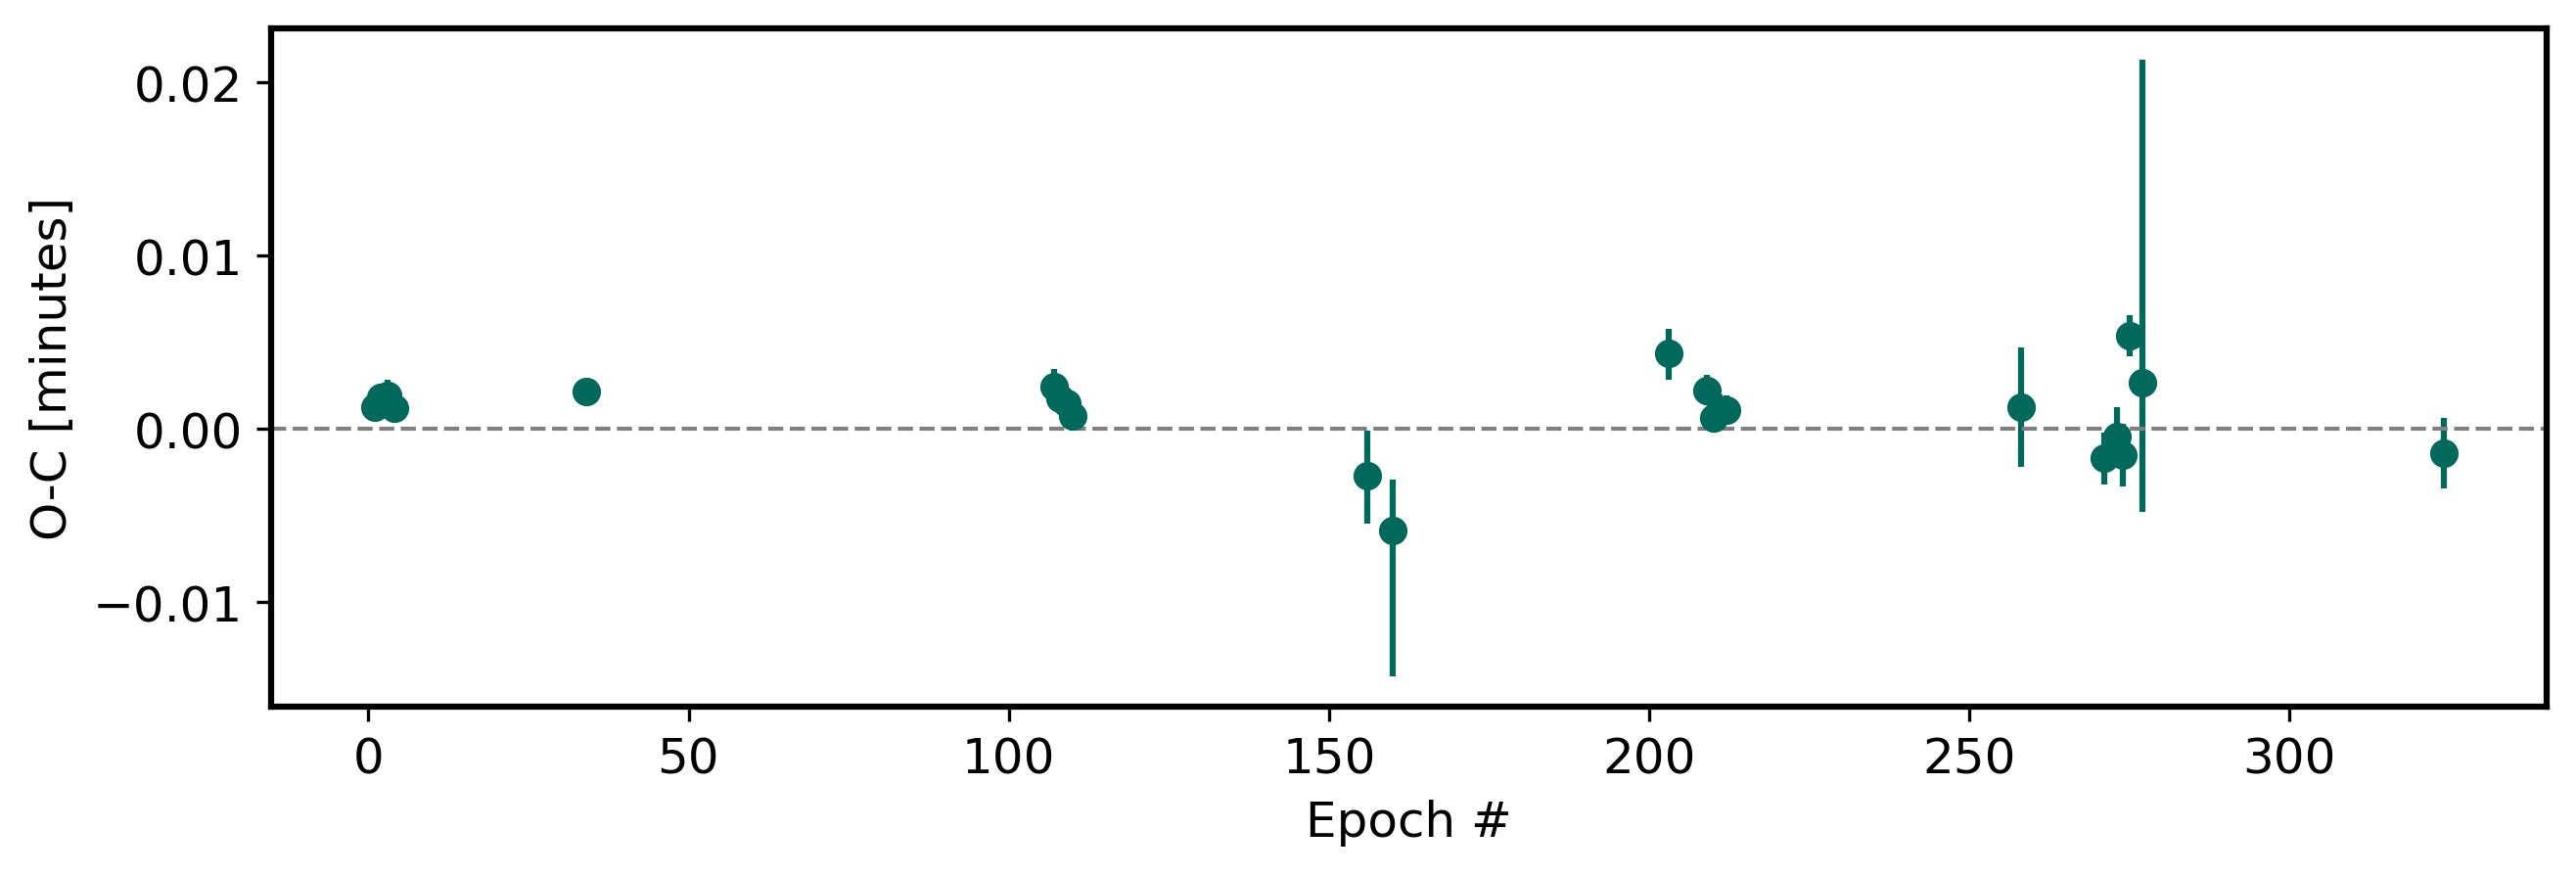

In [6]:
plt.errorbar(b_oc_df.epoch, b_oc_df.OC,  
             yerr=np.vstack([b_oc_df.eTTV_lower.values, b_oc_df.eTTV_upper.values]), fmt = 'o')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.xlabel("Epoch #")
plt.ylabel("O-C [minutes]")
plt.show()

In [7]:
c_oc_df = compute_ttv_dataframe(
    transit_file=c_transit_file,
    t0_nom=c_params['t0'],
    period_nom=c_params['period'],
    t0_err_up=c_params['t0_err_up'],
    t0_err_down=c_params['t0_err_down'],
    period_err_up=c_params['period_err_up'],
    period_err_down=c_params['period_err_down'],
    epoch_offset=1,
)
c_oc_df

,epoch,inst,obs_t0,obs_t0_err_up,obs_t0_err_down,OC,eTTV_upper,eTTV_lower
0,1,TESS,2.458603e+06,0.001302,0.001428,-0.003134,0.001642,0.002377
1,2,TESS,2.458617e+06,0.001639,0.001691,-0.002130,0.001920,0.002544
2,53,TESS,2.459348e+06,0.001891,0.001948,-0.004870,0.002143,0.002807
3,102,TESS,2.460050e+06,0.000981,0.000949,-0.003654,0.001420,0.002504
4,103,TESS,2.460065e+06,0.001238,0.001196,-0.003591,0.001609,0.002614
5,128,MuSCAT4,2.460423e+06,0.006359,0.007609,0.000135,0.006444,0.008017
6,129,LCOGT,2.460437e+06,0.000857,0.000871,0.004882,0.001350,0.002680
7,131,ASTEP,2.460466e+06,0.002567,0.002679,-0.006366,0.002771,0.003700
8,132,ASTEP,2.460480e+06,0.005987,0.005296,0.008729,0.006077,0.005883
9,134,ASTEP,2.460509e+06,0.009219,0.013908,0.002016,0.009278,0.014145


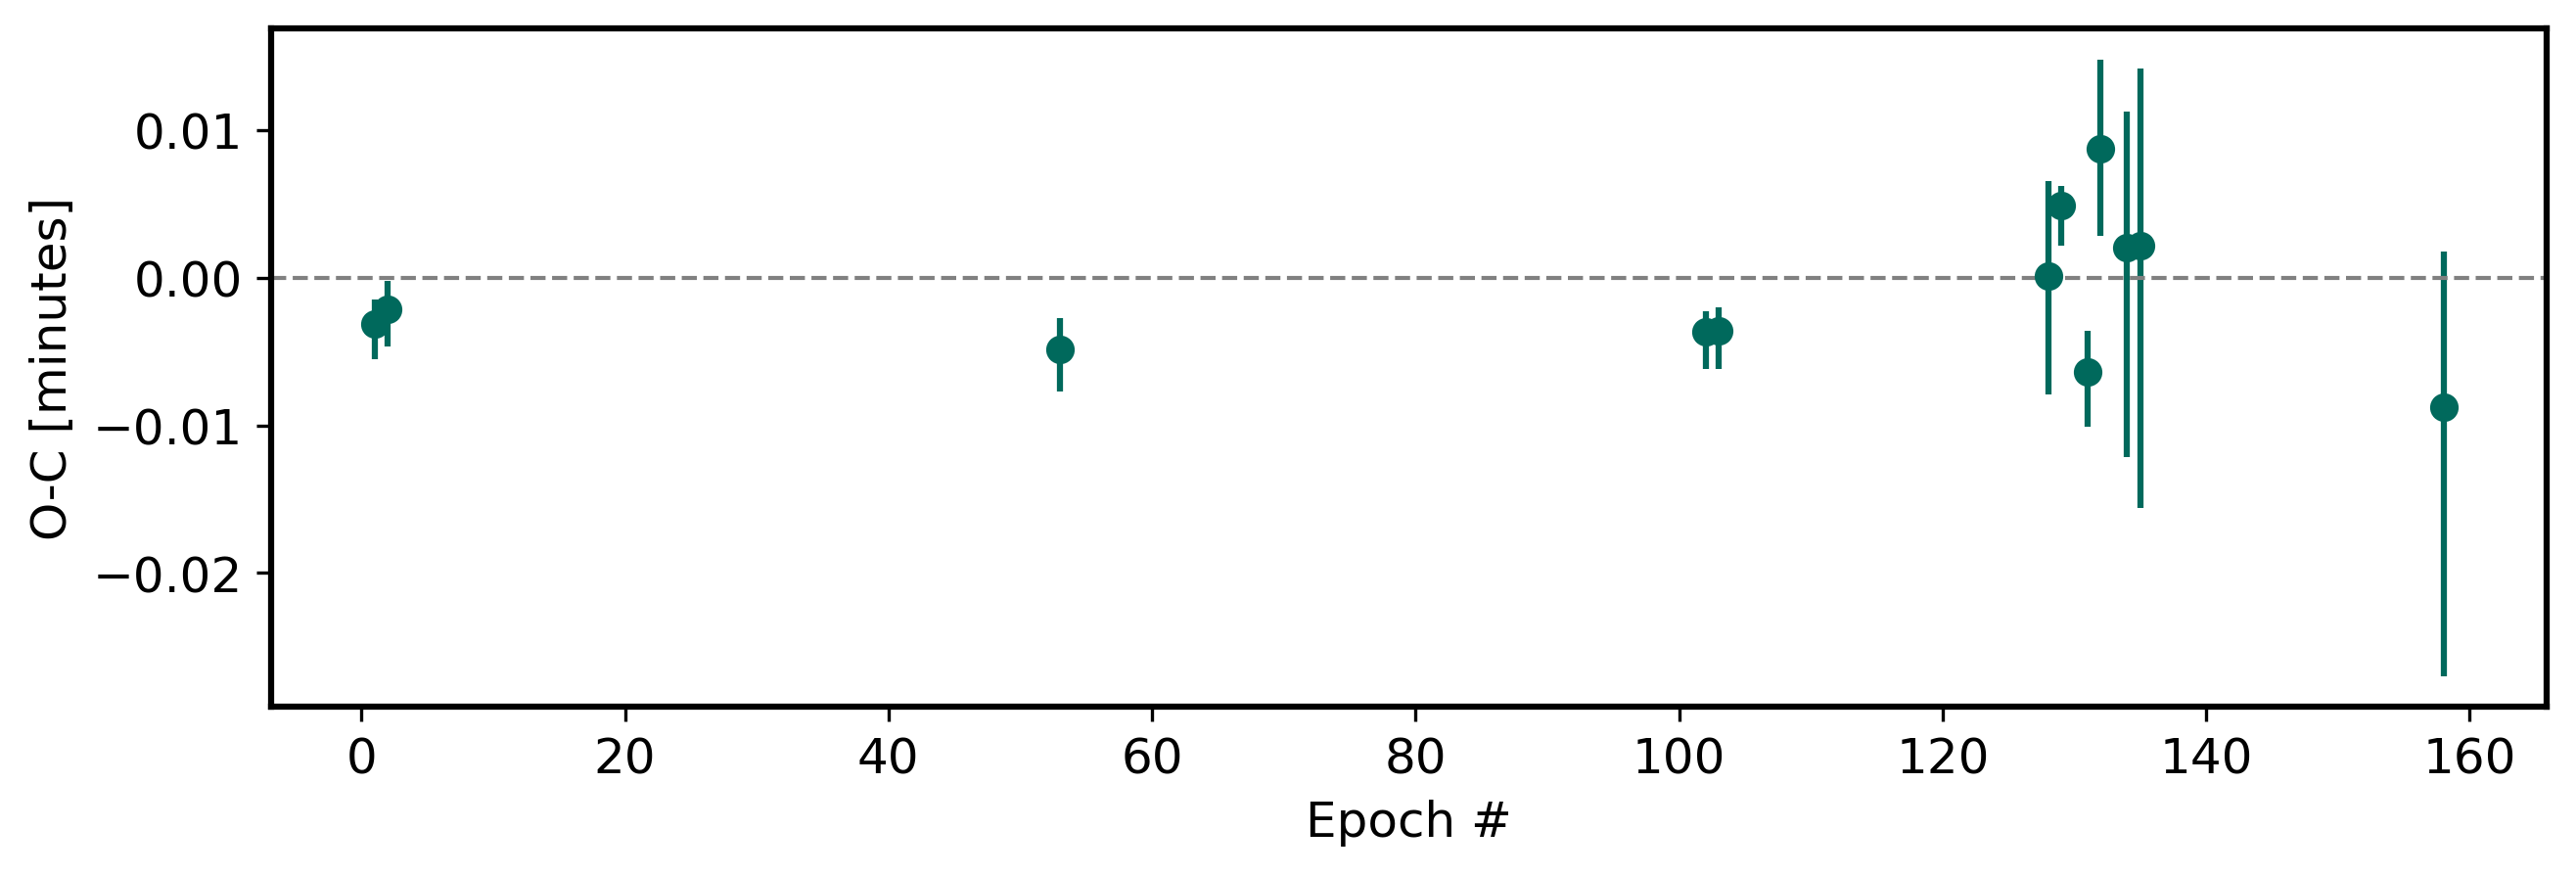

In [8]:
plt.errorbar(c_oc_df.epoch, c_oc_df.OC,  
             yerr=np.vstack([c_oc_df.eTTV_lower.values, c_oc_df.eTTV_upper.values]), fmt = 'o')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.xlabel("Epoch #")
plt.ylabel("O-C [minutes]")
plt.show()

# 3. Lets use TESS-derived eccentricity and argument of periapsis as initalization 

In [9]:
# -------------------------------------------------------------------
# Load MCMC chain from TESS analysis
# -------------------------------------------------------------------
tess_chain_file =  data_dir / "TESS_chain.csv"

df = pd.read_csv(
    tess_chain_file,
    skiprows=1,
    names=["sesinw_b", "secosw_b", "sesinw_c", "secosw_c"],
)

# -------------------------------------------------------------------
# Compute orbital parameters
# -------------------------------------------------------------------

# Eccentricity: e = (√e sinω)^2 + (√e cosω)^2
df["e_b"] = df["sesinw_b"]**2 + df["secosw_b"]**2
df["e_c"] = df["sesinw_c"]**2 + df["secosw_c"]**2

# Argument of periapsis: ω = arctan2(√e sinω, √e cosω)
df["w_b"] = np.arctan2(df["sesinw_b"], df["secosw_b"])
df["w_c"] = np.arctan2(df["sesinw_c"], df["secosw_c"])

# Ensure ω is in the range [0, 2π]
df["w_b"] = np.mod(df["w_b"], 2 * np.pi)
df["w_c"] = np.mod(df["w_c"], 2 * np.pi)

# Convert to degrees for interpretability
df["w_b_deg"] = np.degrees(df["w_b"])
df["w_c_deg"] = np.degrees(df["w_c"])

df.head()

,sesinw_b,secosw_b,sesinw_c,secosw_c,e_b,e_c,w_b,w_c,w_b_deg,w_c_deg
0,-0.122804,-0.457807,-0.183449,-0.677764,0.224668,0.493018,3.403667,3.405927,195.015761,195.14524
1,-0.122804,-0.457807,-0.183449,-0.677764,0.224668,0.493018,3.403667,3.405927,195.015761,195.14524
2,-0.122804,-0.457807,-0.183449,-0.677764,0.224668,0.493018,3.403667,3.405927,195.015761,195.14524
3,-0.122804,-0.457807,-0.183449,-0.677764,0.224668,0.493018,3.403667,3.405927,195.015761,195.14524
4,-0.122804,-0.457807,-0.183449,-0.677764,0.224668,0.493018,3.403667,3.405927,195.015761,195.14524


In [10]:
# -------------------------------------------------------------------
# Summary statistics from posterior samples
# -------------------------------------------------------------------

b_ecc = np.median(df["e_b"])
c_ecc = np.median(df["e_c"])

b_omega = np.median(df["w_b"])
c_omega = np.median(df["w_c"])

# -------------------------------------------------------------------
# Initial mass guesses (for MCMC initialization)
# -------------------------------------------------------------------

EARTH_TO_SOLAR = 3.00274e-6  # conversion factor

b_mass_earth = 20
c_mass_earth = 15

b_mass = b_mass_earth * EARTH_TO_SOLAR
c_mass = c_mass_earth * EARTH_TO_SOLAR

# 4. Set parameters for the MCMC fit 

In [11]:
# -------------------------------------------------------------------
# Assign transit timing data for each planet
# -------------------------------------------------------------------

b_df = b_oc_df.copy()
c_df = c_oc_df.copy()

# Observed mid-transit times
observed_time_b = b_df["obs_t0"].to_numpy()
observed_time_c = c_df["obs_t0"].to_numpy()

# Asymmetric timing uncertainties
err_up_b = b_df["obs_t0_err_up"].to_numpy()
err_down_b = b_df["obs_t0_err_down"].to_numpy()

err_up_c = c_df["obs_t0_err_up"].to_numpy()
err_down_c = c_df["obs_t0_err_down"].to_numpy()

# -------------------------------------------------------------------
# Define system parameters for the TTV model
# -------------------------------------------------------------------

planet_periods = [b_params['period'], c_params['period']]
planet_t0s = [b_params['t0'], c_params['t0']]
planet_params = (b_params['period'], c_params['period'], b_params['t0'], c_params['t0'])

# Number of transits to include in the basis function calculation
n_transits_b = 350
n_transits_c = int(round(b_params['period'] * n_transits_b / c_params['period']))

# -------------------------------------------------------------------
# Generate basis function matrices
# -------------------------------------------------------------------

M_b, M_c = MultiplanetSystemBasisFunctionMatrices(
    2,
    planet_periods,
    planet_t0s,
    [n_transits_b, n_transits_c],
)

# -------------------------------------------------------------------
# Configuration
# -------------------------------------------------------------------

use_mass_prior = False
save_results = True

outdir = "results"
os.makedirs(outdir, exist_ok=True)

# Initial parameter vector:
# [ecc_b, ecc_c, omega_b, omega_c, mass_b, mass_c]
initial_params = np.array([b_ecc, c_ecc, b_omega, c_omega, b_mass, c_mass])

ndim = len(initial_params)
nwalkers = 100 if save_results else 30
nsteps = 100_000 if save_results else 5_000

# Small perturbation around the initial guess for each walker
initial_positions = initial_params + 1e-5 * np.random.randn(nwalkers, ndim)

# Use all available CPU cores except one
n_cores = max(1, multiprocessing.cpu_count() - 1)

# Wrap the log-posterior so the mass prior can be toggled on or off
log_post = partial(log_posterior, use_mass_prior=use_mass_prior)

# Bundle sampler inputs for readability
sampler_args = (
    observed_time_b,
    observed_time_c,
    err_up_b,
    err_down_b,
    err_up_c,
    err_down_c,
    b_params['period'],
    c_params['period'],
    b_params['t0'],
    c_params['t0'],
    n_transits_b,
    n_transits_c,
)

# 5. Run MCMC to determine best parameters 

In [12]:
if __name__ == "__main__":
    with multiprocessing.Pool(n_cores) as pool:
        sampler = emcee.EnsembleSampler(
            nwalkers,
            ndim,
            log_post,
            args=sampler_args,
            pool=pool,
        )
        sampler.run_mcmc(initial_positions, nsteps, progress=True)

    samples = sampler.get_chain(flat=True)

    if save_results:
        df_samples = pd.DataFrame(
            samples,
            columns=["ecc_b", "ecc_c", "omega_b", "omega_c", "mass_b", "mass_c"],
        )
        outfile = os.path.join(outdir, "mcmc_samples.csv")
        df_samples.to_csv(outfile, index=False)
        print(f"Samples saved to {outfile}")

    print(f"Mean acceptance fraction: {np.mean(sampler.acceptance_fraction):.3f}")

100%|█████████████████████████████████| 100000/100000 [1:51:44<00:00, 14.92it/s]


Samples saved to results/mcmc_samples.csv
Mean acceptance fraction: 0.148


The mean MCMC acceptance fraction was 0.195, which is slightly below the typical target range but still close enough to suggest the sampler was exploring parameter space reasonably well. This indicates somewhat conservative proposal behavior, so convergence diagnostics such as trace plots and posterior stability checks are especially important.

# 6. MCMC Diagnostics

To assess sampler behavior, I inspect the parameter chains and acceptance fraction. These diagnostics help determine whether the posterior samples are stable and representative of the target distribution.

In [13]:
#discard first values samples as burn-in
discard = int(nsteps*0.15) 

flat_samples = sampler.get_chain(discard=discard, flat=True)
# max probability
probs = sampler.get_log_prob(discard=discard,flat=True)
l = np.where(probs == np.max(probs))
if np.size(l)>1:
    l = np.squeeze(l)[0]
result = np.squeeze(flat_samples[l])
result_err = np.std(flat_samples, axis=0)
print ("Input values:", initial_params)
print ("Best fit values:", result)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Input values: [6.41140582e-02 7.68750404e-02 3.40778047e+00 3.25708322e+00
 6.00548000e-05 4.50411000e-05]
Best fit values: [1.97606241e-02 6.88613847e-04 5.24558431e+00 4.05378236e+00
 6.53788436e-05 6.13718319e-05]


In [14]:
labels = ["ecc_b", "ecc_c", "omega_b", "omega_c", "mass_b", "mass_c"]

/var/folders/rk/888fv3n533n_d0tlr213d9h40000gn/T/ipykernel_63836/2077966337.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


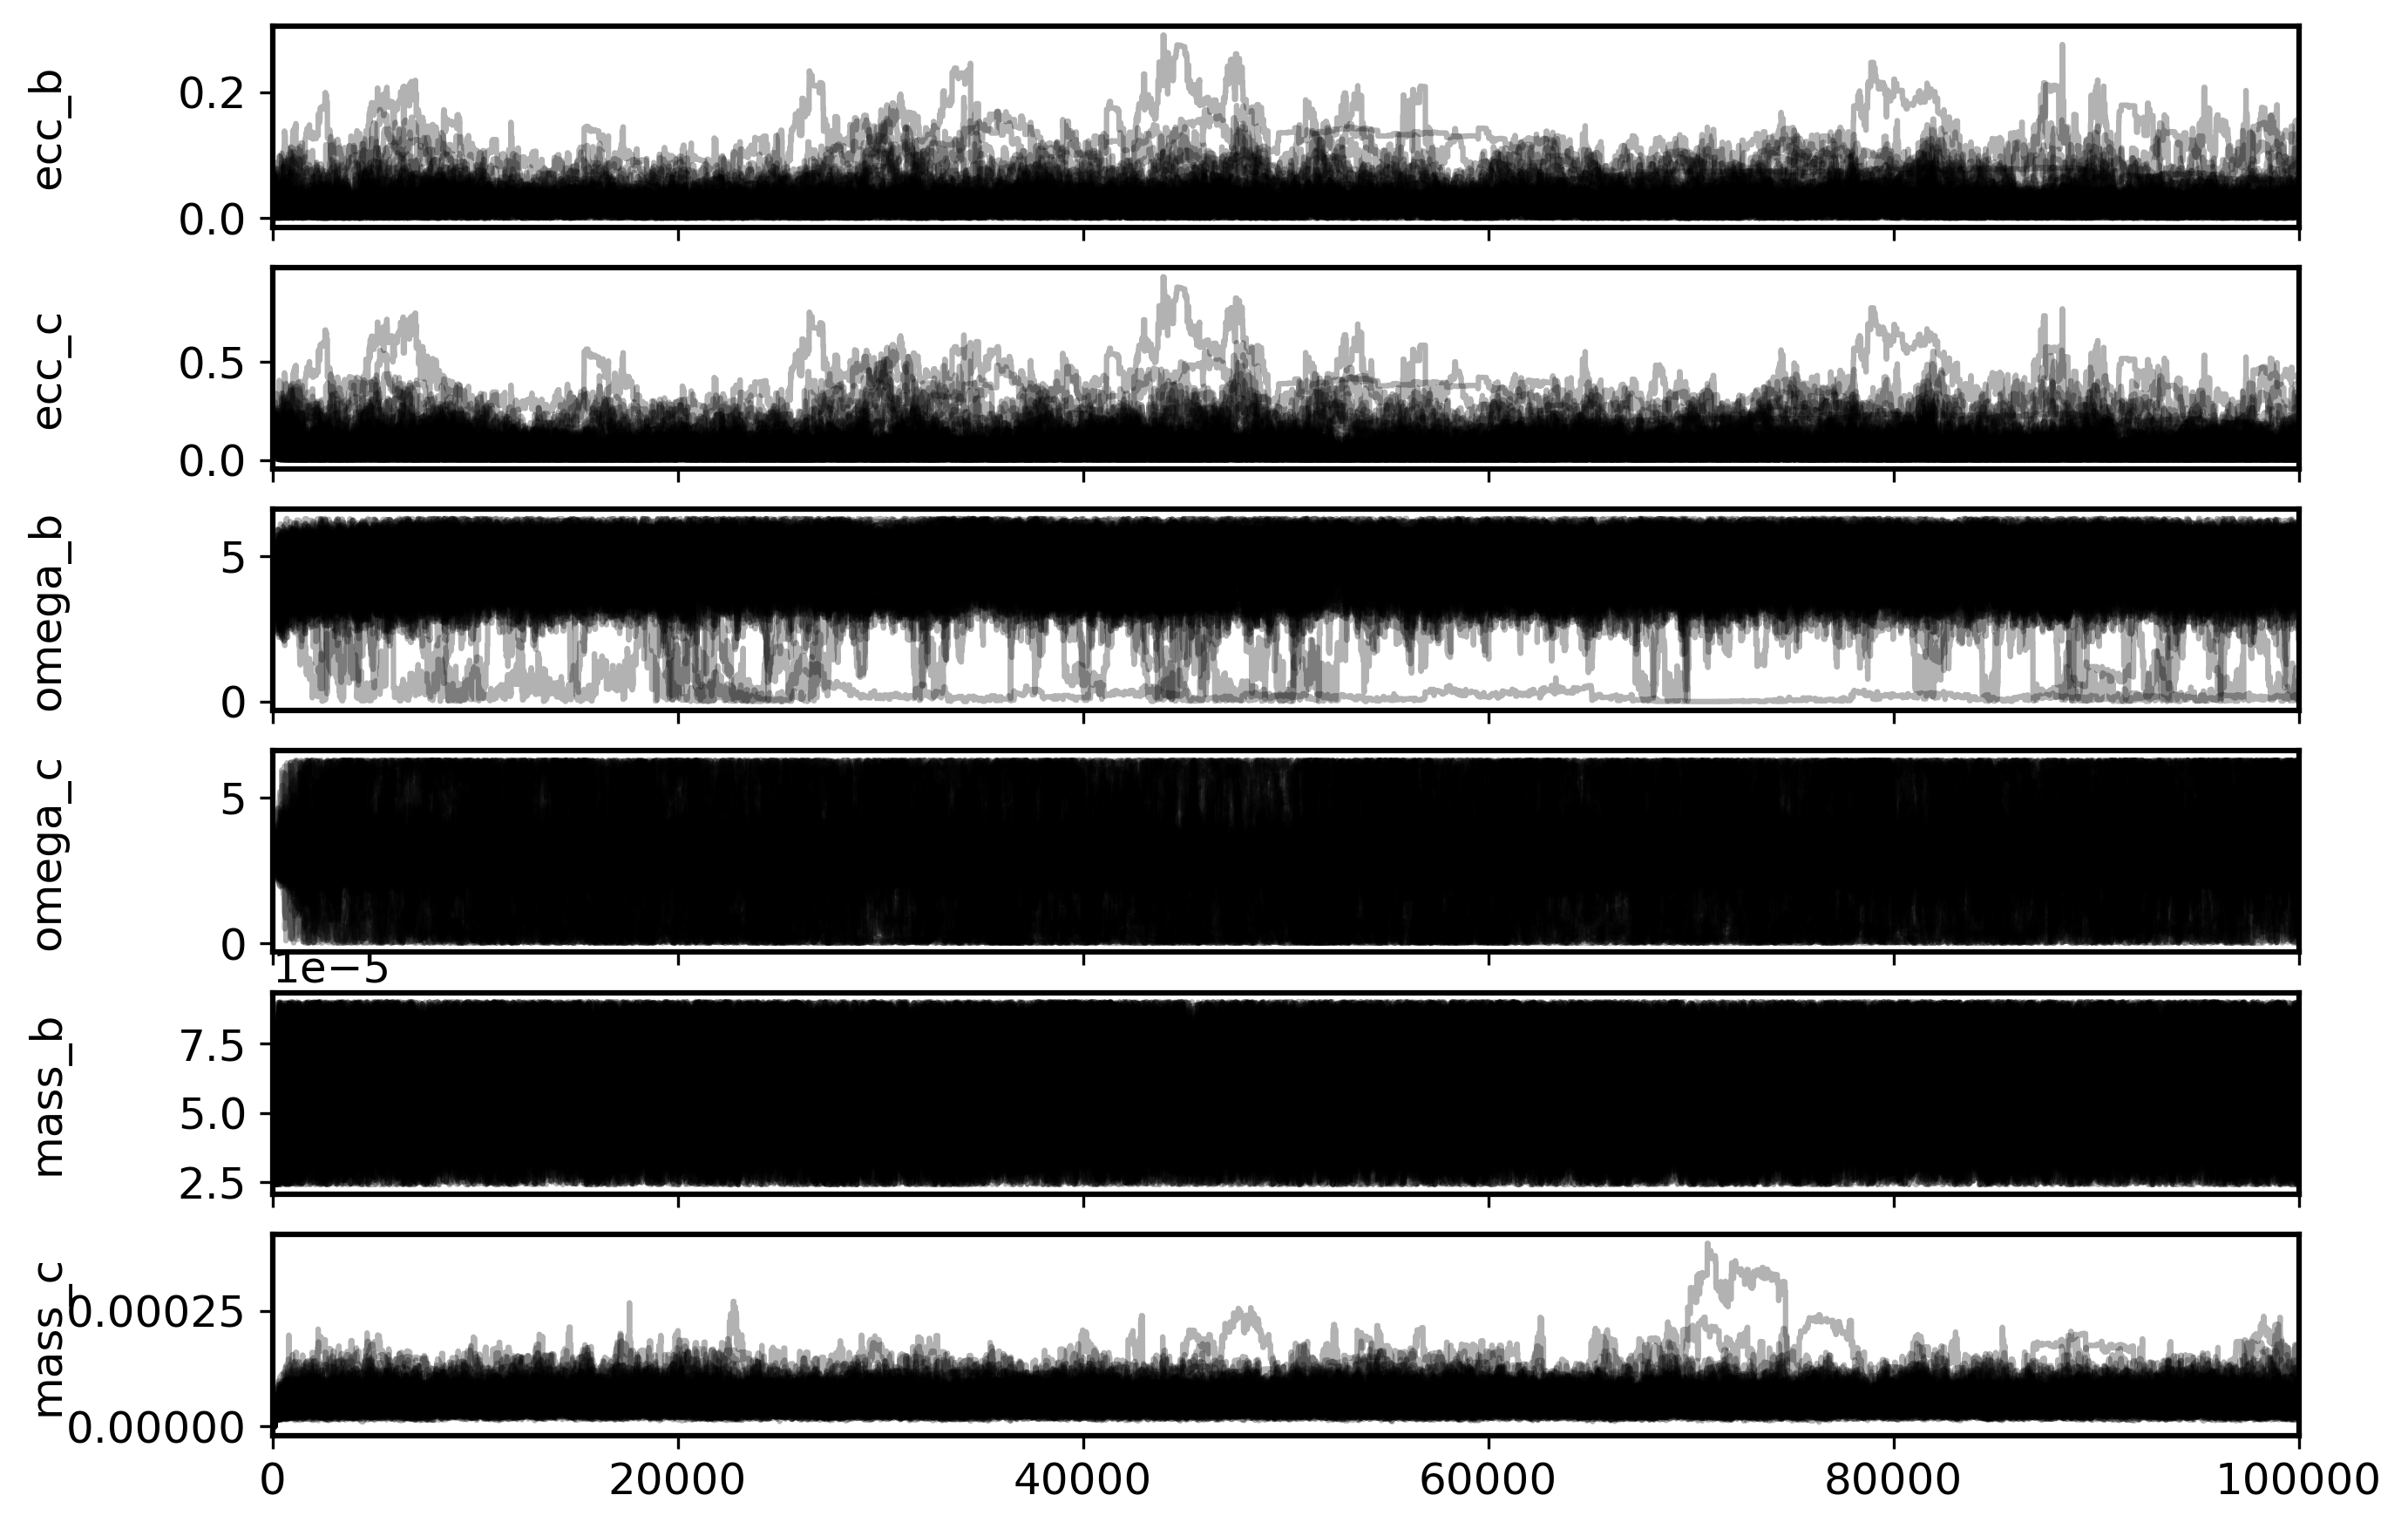

In [16]:
#make a pairs plot from MCMC output
burn = sampler.iteration//2
samples = sampler.get_chain()
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
for i in range(ndim):
     ax = axes[i]
     ax.plot(samples[:, :, i], "k", alpha=0.3)
     ax.set_xlim(0, len(samples))
     ax.set_ylabel(labels[i])
     ax.yaxis.set_label_coords(-0.1, 0.5)
fig.set_rasterized(True)
if save_results:
    fig.savefig(os.path.join(outdir, "mcmcsteps.png"))
fig.show()

The trace plots indicate that the chains move away from their initial values quickly and then explore stable regions of parameter space. While mixing is not perfect and the acceptance fraction is slightly low (~0.20), there is no clear evidence of divergence or instability.

The eccentricities are reasonably well constrained, while the mass of planet c remains weakly constrained and concentrated at low values. Overall, the sampler appears to be exploring the posterior sufficiently for qualitative interpretation.

# 7. Extract posterior samples 

In [17]:
ecc_b, ecc_c = flat_samples[:, 0], flat_samples[:, 1]
omega_b, omega_c = flat_samples[:, 2], flat_samples[:, 3]
mass_b, mass_c = flat_samples[:, 4], flat_samples[:, 5]

omega_b_deg = np.degrees(omega_b)
omega_c_deg = np.degrees(omega_c)

mass_b_earth = mass_b / EARTH_TO_SOLAR
mass_c_earth = mass_c / EARTH_TO_SOLAR

/var/folders/rk/888fv3n533n_d0tlr213d9h40000gn/T/ipykernel_63836/3149113010.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


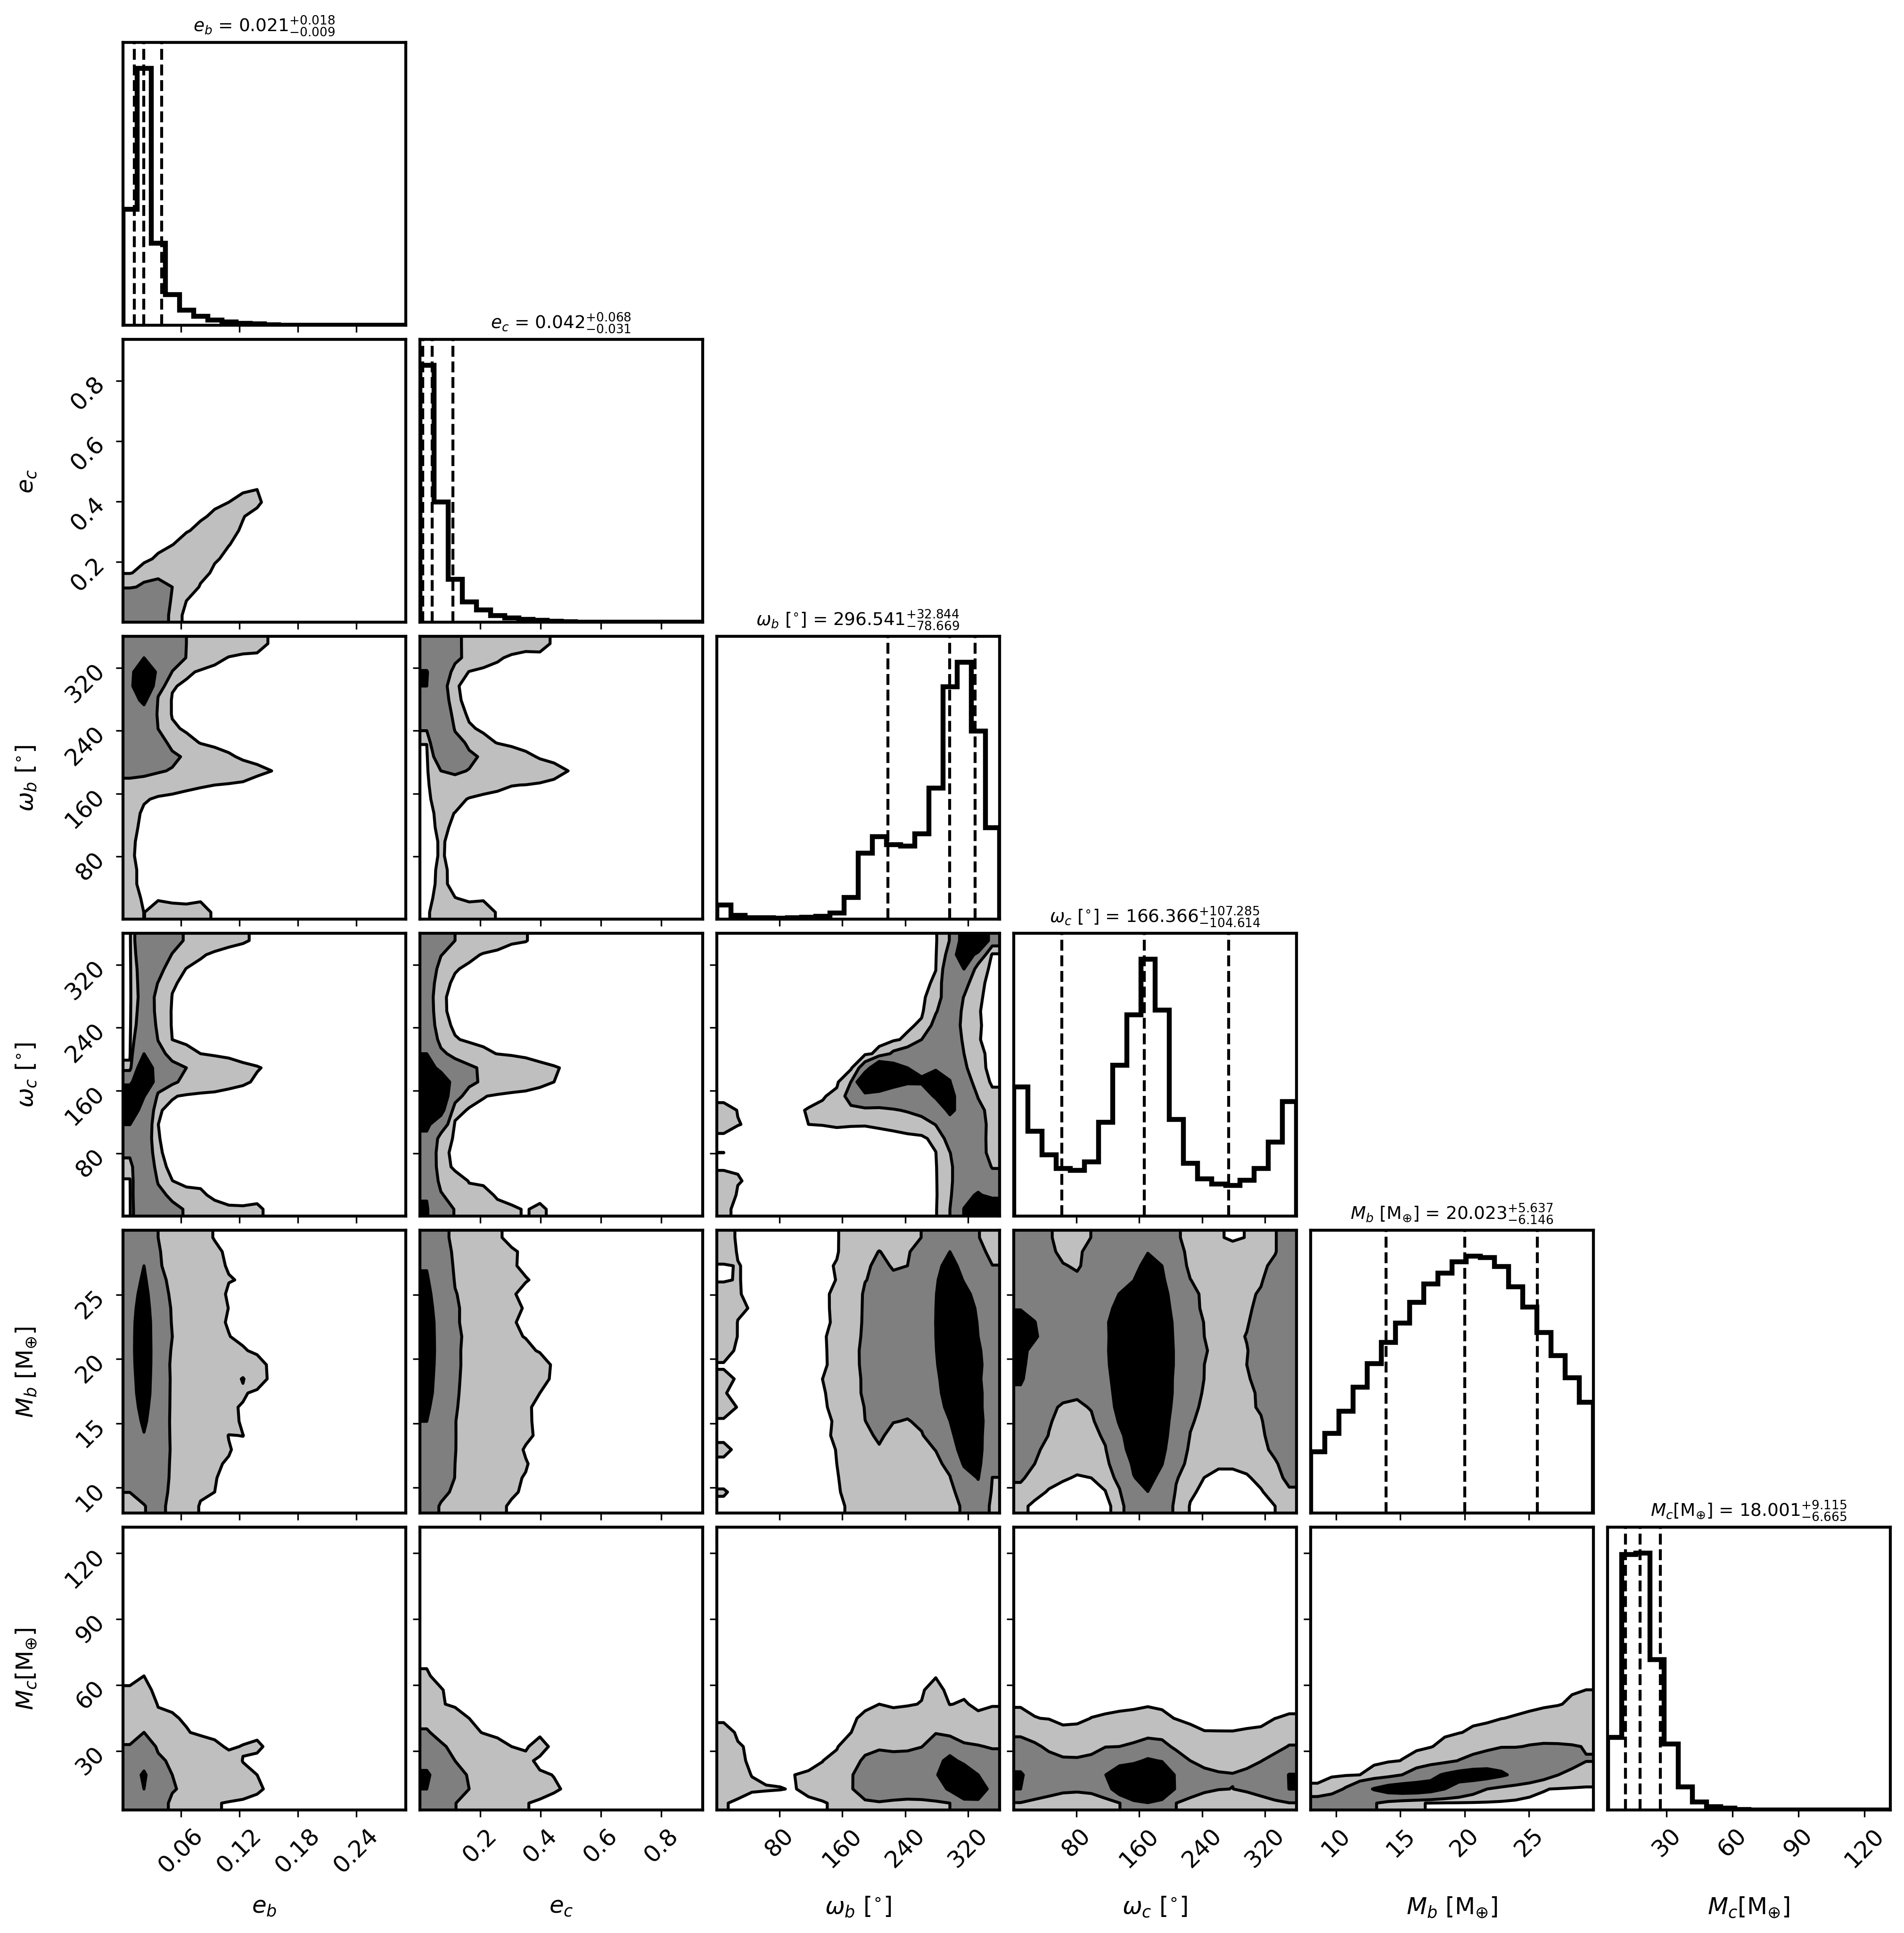

In [18]:
import corner 
samples_for_corner = np.column_stack([
    ecc_b,
    ecc_c,
    omega_b_deg,
    omega_c_deg,
    mass_b_earth,
    mass_c_earth,
])

corner_labels = ['$e_{b}$', '$e_{c}$', 
                 '$\omega_{b}$ [$^{\circ}$]',  '$\omega_{c}$ [$^{\circ}$]',  
                 '$M_{b}$ [M$_{\oplus}]$',  '$M_{c}$[M$_{\oplus}$]', ]

fig = corner.corner( 
    samples_for_corner,show_titles=True,labels=corner_labels,quantiles=(0.16, 0.5, 0.84),
    fill_contours=True, plot_datapoints=False,title_kwargs={"fontsize": 9},title_fmt='.3f',
    hist_kwargs={"linewidth": 2.5},levels=[(1-np.exp(-0.5)),(1-np.exp(-2)),(1-np.exp(-4.5))]
);
if save_results:
    fig.savefig(os.path.join(outdir, "corner.png"))
fig.show()

# 8. Plot the best fit 

In [19]:
# -------------------------------------------------------------------
# Best-fit parameter values
# -------------------------------------------------------------------

best_fit_params = result
best_fit_errors = result_err

ecc_b, ecc_c, omega_b, omega_c, mass_b, mass_c = best_fit_params


# Compute best-fit TTV model
times_b, ttv_b, times_c, ttv_c = calculate_twopl_ttvs(
    mass_b,
    mass_c,
    ecc_b,
    ecc_c,
    omega_b,
    omega_c,
    *planet_params,
    n_transits_b,
    n_transits_c,
)

In [23]:
# -------------------------------------------------------------------
# Helper functions 
# -------------------------------------------------------------------

def chi_square_asym(observed, calculated, error_up, error_down):
    residuals = observed - calculated
    errors = np.where(residuals > 0, error_up, error_down)
    return np.sum((residuals / errors) ** 2)

def chi_square_two_planets(
    observed_b,
    calculated_b,
    err_up_b,
    err_down_b,
    observed_c,
    calculated_c,
    err_up_c,
    err_down_c,
):
    chi_b = chi_square_asym(observed_b, calculated_b, err_up_b, err_down_b)
    chi_c = chi_square_asym(observed_c, calculated_c, err_up_c, err_down_c)
    return chi_b + chi_c


def reduced_chi_square_two_planets(
    observed_b,
    calculated_b,
    err_up_b,
    err_down_b,
    observed_c,
    calculated_c,
    err_up_c,
    err_down_c,
    n_params):
    
    # Total chi-square
    chi2 = chi_square_two_planets(
        observed_b,
        calculated_b,
        err_up_b,
        err_down_b,
        observed_c,
        calculated_c,
        err_up_c,
        err_down_c,
    )

    # Total number of data points
    N = len(observed_b) + len(observed_c)

    # Degrees of freedom
    dof = N - n_params

    if dof <= 0:
        raise ValueError("Degrees of freedom must be positive.")

    chi2_red = chi2 / dof

    return chi2, chi2_red
                                                               

def find_closest_indices(observed_times, model_times):
    observed_times = np.asarray(observed_times)
    model_times = np.asarray(model_times)

    indices = []
    for obs_time in observed_times:
        idx = np.argmin(np.abs(model_times - obs_time))
        indices.append(idx)

    return np.array(indices)


In [24]:
# -------------------------------------------------------------------
# Calculate the chi square for the fit  
# -------------------------------------------------------------------

idx_b = find_closest_indices(b_oc_df["obs_t0"], times_b)
idx_c = find_closest_indices(c_oc_df["obs_t0"], times_c)


chi2, chi2_red = reduced_chi_square_two_planets(
    b_oc_df["OC"],
    ttv_b[idx_b],
    b_oc_df["eTTV_upper"],
    b_oc_df["eTTV_lower"],
    c_oc_df["OC"],
    ttv_c[idx_c],
    c_oc_df["eTTV_upper"],
    c_oc_df["eTTV_lower"],
    n_params=6,
)

print(f"Chi-square: {chi2:.2f}")
print(f"Reduced chi-square: {chi2_red:.2f}")

Chi-square: 35.56
Reduced chi-square: 1.23


The reduced chi-square is 1.23, indicating that the model provides a reasonably good fit to the data given the estimated uncertainties. The value being slightly greater than 1 suggests that there may be minor unmodeled structure in the data or slight underestimation of uncertainties, but overall the fit is consistent with expectations.

In [30]:
from matplotlib.colors import to_rgba
from matplotlib.lines import Line2D

### From coolors 
colors = ['#588B8B', '#C4ABAB', '#FFD5C2', '#F28F3B', '#C8553D', '#4C517A', '#93B7BE']

# === Define colors for each instrument ===
instrument_colors = {
    'TESS': colors[0],
    'Spitzer': colors[1],
    'MuSCAT4':colors[2],
    'JWST': colors[3],
    'LCOGT': colors[4],
    'SOAR': colors[5],
    'ASTEP': colors[6],
}

/var/folders/rk/888fv3n533n_d0tlr213d9h40000gn/T/ipykernel_63836/3151682742.py:163: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


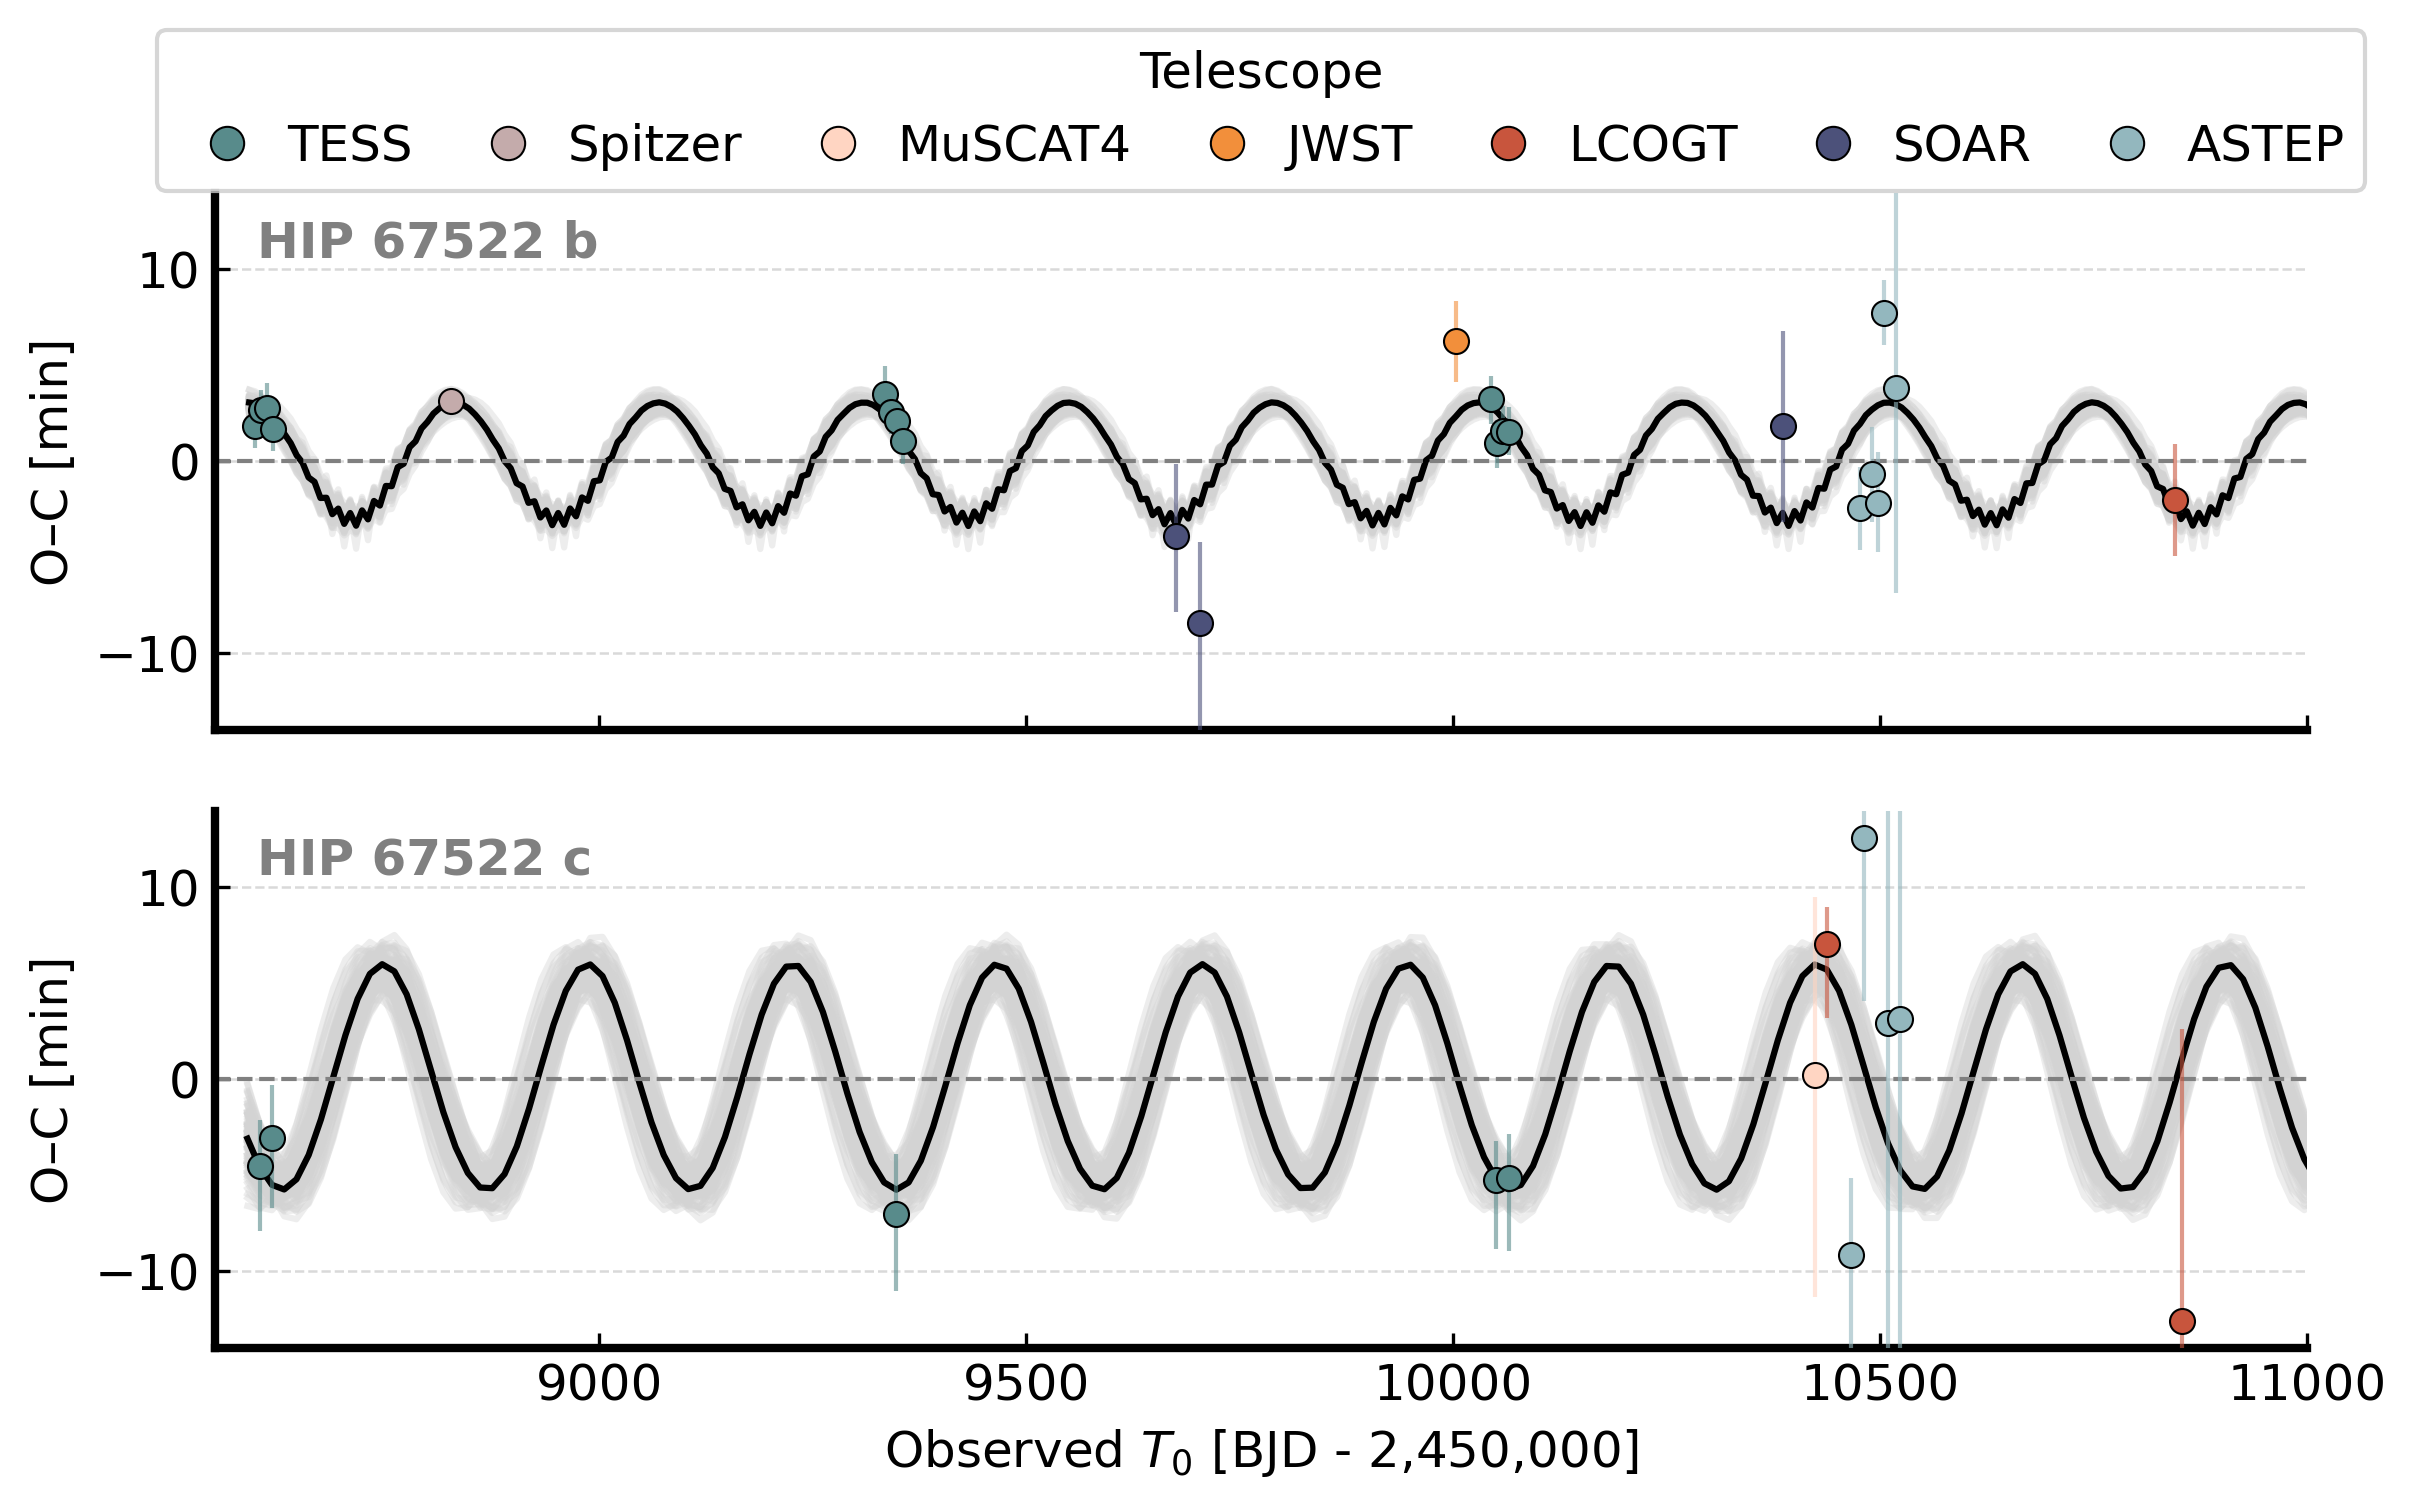

In [32]:
# -------------------------------------------------------------------
# Plot configuration
# -------------------------------------------------------------------

num_draws = 100
random_indices = np.random.choice(flat_samples.shape[0], num_draws, replace=False)

time_offset = 2450000
num_draws = len(random_indices)

fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(9, 5),
    sharex=True,
    gridspec_kw={"hspace": 0.15},
)

# -------------------------------------------------------------------
# Draw posterior samples
# -------------------------------------------------------------------

for idx in random_indices:
    sample_ecc_b, sample_ecc_c, sample_omega_b, sample_omega_c, sample_mass_b, sample_mass_c = flat_samples[idx, :]

    sample_times_b, sample_ttv_b, sample_times_c, sample_ttv_c = calculate_twopl_ttvs(
        sample_mass_b,
        sample_mass_c,
        sample_ecc_b,
        sample_ecc_c,
        sample_omega_b,
        sample_omega_c,
        *planet_params,
        n_transits_b,
        n_transits_c,
    )

    ax1.plot(
        sample_times_b - time_offset,
        sample_ttv_b * 1440,
        color="lightgray",
        alpha=0.4,
        zorder=1,
    )
    ax2.plot(
        sample_times_c - time_offset,
        sample_ttv_c * 1440,
        color="lightgray",
        alpha=0.4,
        zorder=1,
    )

# -------------------------------------------------------------------
# Plot best-fit model
# -------------------------------------------------------------------

ax1.plot(times_b - time_offset, ttv_b * 1440, "-", lw=1.5, color="k", zorder=2)
ax2.plot(times_c - time_offset, ttv_c * 1440, "-", lw=1.5, color="k", zorder=2)

# -------------------------------------------------------------------
# Plot observed data by instrument
# -------------------------------------------------------------------

def plot_ttv_data_by_instrument(ax, df, label_text):
    for inst in df["inst"].unique():
        subset = df[df["inst"] == inst]
        base_color = instrument_colors.get(inst, "gray")
        errorbar_color = to_rgba(base_color, alpha=0.6)

        ax.errorbar(
            subset["obs_t0"] - time_offset,
            subset["OC"] * 1440,
            yerr=[subset["eTTV_lower"] * 1440, subset["eTTV_upper"] * 1440],
            fmt="o",
            capsize=0,
            color=base_color,
            ecolor=errorbar_color,
            elinewidth=1,
            markeredgecolor="k",
            markeredgewidth=0.5,
            zorder=3,
        )

    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.grid(which="major", axis="y", linestyle="--", color="0.85", linewidth=0.6)

    ax.text(
        0.02,
        0.95,
        label_text,
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment="top",
        color="gray",
        weight="bold",
    )

plot_ttv_data_by_instrument(ax1, b_oc_df, "HIP 67522 b")
plot_ttv_data_by_instrument(ax2, c_oc_df, "HIP 67522 c")

# -------------------------------------------------------------------
# Axis labels and limits
# -------------------------------------------------------------------

ax1.set_ylabel("O–C [min]")
ax2.set_ylabel("O–C [min]")
ax2.set_xlabel("Observed $T_0$ [BJD - 2,450,000]")

ax1.set_ylim([-14, 14])
ax2.set_ylim([-14, 14])
ax1.set_xlim([8550, 11000])

# -------------------------------------------------------------------
# Styling
# -------------------------------------------------------------------

for ax in (ax1, ax2):
    ax.tick_params(
        axis="both",
        which="both",
        direction="in",
        top=False,
        bottom=True,
        left=True,
        right=False,
    )

    ax.spines["bottom"].set_linewidth(2)
    ax.spines["left"].set_linewidth(2)
    ax.spines["top"].set_linewidth(0)
    ax.spines["right"].set_linewidth(0)

# -------------------------------------------------------------------
# Custom legend
# -------------------------------------------------------------------

legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markeredgecolor="k",
        markeredgewidth=0.5,
        markerfacecolor=color,
        markersize=8,
        label=inst,
    )
    for inst, color in instrument_colors.items()
]

ax1.legend(
    title="Telescope",
    handles=legend_handles,
    facecolor="white",
    loc="upper center",
    bbox_to_anchor=(0.50, 1.35),
    ncol=7,
    handletextpad=0.2,
    columnspacing=0.9,
)

plt.tight_layout()

if save_results:
    fig.savefig(os.path.join(outdir, "best_oc.png"))

plt.show()

# 8. Lets compare masses 

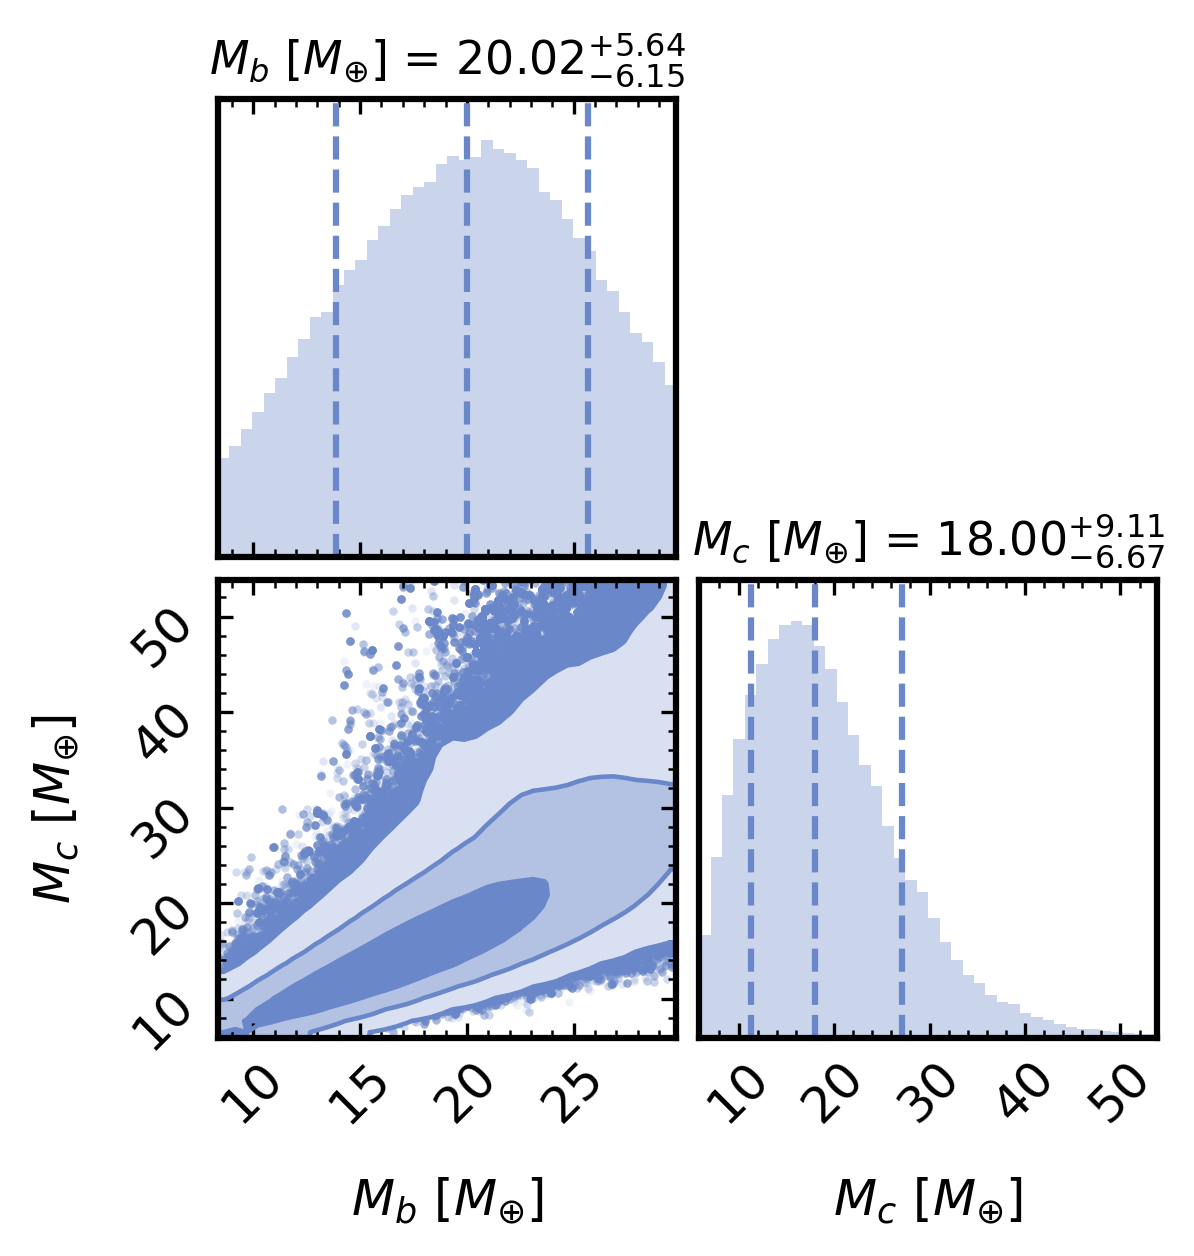

In [35]:
masses_sample = np.column_stack([mass_b_earth, mass_c_earth])

# Optional: crop to central 99% to avoid long empty tails
ranges = []
for k in range(masses_sample.shape[1]):
    lo, hi = np.percentile(masses_sample[:, k], [0.5, 99.5])
    ranges.append((lo, hi))

# Standard 2D Gaussian 1σ / 2σ / 3σ enclosed-probability levels
levels = 1.0 - np.exp(-0.5 * np.array([1.0, 2.0, 3.0])**2)

fig = plt.figure(figsize=(4.2, 4.2))

fig = corner.corner(
    masses_sample,
    fig=fig,
    labels=[r"$M_b$ [$M_{\oplus}$]", r"$M_c$ [$M_{\oplus}$]"],
    range=ranges,
    bins=40,
    color='#6987C9',
    smooth=0.9,
    levels=levels,
    plot_density=False,          # keep contours + scatter only
    plot_contours=True,
    fill_contours=True,
    plot_datapoints=True,
    max_n_ticks=5,
    quantiles=[0.16, 0.5, 0.84], # add vertical lines on 1D hists
    show_titles=True,
    title_fmt=".2f",
    label_kwargs={"fontsize":12},
    title_kwargs={"fontsize":11},

    # Scatter point style
    scatter_kwargs={"alpha":0.25, "s":6, "rasterized":True},

    # Contour line style
    contour_kwargs={"linewidths":1.1},

    # Histogram style
    hist_kwargs={"density":True, "histtype":"stepfilled", "alpha":0.35, "linewidth":1.0},
)

for ax in fig.get_axes():
    # Make all spines visible
    for spine in ax.spines.values():
        spine.set_visible(True)
    ax.tick_params(which='both', direction='in', top=True, right=True)
    ax.minorticks_on()

if save_results:
    fig.savefig(os.path.join(outdir, "mass_b_vs_c.png"), dpi=300, bbox_inches="tight")
plt.show()

The corner plot shows the posterior distributions for the masses of planets b and c. Planet b is reasonably well constrained, with a median mass of approximately 19 Earth masses and moderate uncertainty. This is notable given that no external mass prior was applied in the fit.

In contrast, the mass of planet c is more weakly constrained, with a broader and more asymmetric posterior distribution. The extended tail toward higher masses suggests that the TTV data alone do not tightly restrict its value.

The joint posterior distribution reveals a clear positive correlation between the two masses. This indicates a degeneracy in the TTV model: increases in the mass of one planet can be partially compensated by increases in the mass of the other while still producing similar timing signals.